# IMU Swimming Data — Step-by-Step Signal Processing

*For thesis: Designing for Breathing-Stroke Coordination Awareness in Front Crawl Swimming*

This notebook walks through every signal processing step with visualizations at each stage.


In [1]:
# ── Participant parameters ──
PID         = "EP01"
HEAD_FILE   = "/content/drive/My Drive/Colab Notebooks/swimming/EP01_HeadMotion.csv"
WRIST_FILE  = "/content/drive/My Drive/Colab Notebooks/swimming/EP01_WristMotion.csv"
BREATH_SIDE = "right"
TRIM_START  = 120
TRIM_END    = 30
BR_PROM_DEG = 100.0
MIN_BR_IBI  = 1.5
MIN_STR_IBI = 0.7

## Step 1 — Install and Import

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import signal as sp
from google.colab import files
import io, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

print("Ready.")

ModuleNotFoundError: No module named 'plotly'

## Step 2 — Load from Google Drive

Load **HeadMotion** CSV and **WristMotion** CSV from drive. The notebook will auto-detect which is which from the filename.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

head_raw  = pd.read_csv('/content/drive/My Drive/Colab Notebooks/swimming/My_HeadMotion.csv')
wrist_raw = pd.read_csv('/content/drive/My Drive/Colab Notebooks/swimming/My_WristMotion.csv')

print(f"Head  : {len(head_raw):,} rows")
print(f"Wrist : {len(wrist_raw):,} rows")

# step 1: create time columns first
head_raw["t_abs"]  = head_raw["time"]  / 1e9
wrist_raw["t_abs"] = wrist_raw["time"] / 1e9
head_raw["t_s"]    = head_raw["t_abs"]  - head_raw["t_abs"].iloc[0]
wrist_raw["t_s"]   = wrist_raw["t_abs"] - wrist_raw["t_abs"].iloc[0]

# step 2: now trim using t_s
TRIM_START = 220
TRIM_END   = 20

head_raw  = head_raw[(head_raw["t_s"] >= TRIM_START) &
                     (head_raw["t_s"] <= head_raw["t_s"].max() - TRIM_END)].reset_index(drop=True)
wrist_raw = wrist_raw[(wrist_raw["t_s"] >= TRIM_START) &
                      (wrist_raw["t_s"] <= wrist_raw["t_s"].max() - TRIM_END)].reset_index(drop=True)

# step 3: reset t_s to start from 0 after trimming
head_raw["t_s"]  = head_raw["t_s"]  - head_raw["t_s"].iloc[0]
wrist_raw["t_s"] = wrist_raw["t_s"] - wrist_raw["t_s"].iloc[0]

print(f"After trimming — Head: {head_raw['t_s'].max():.1f}s, Wrist: {wrist_raw['t_s'].max():.1f}s")

MessageError: Error: credential propagation was unsuccessful

## Step 3 — Understanding the Raw Data

Every row = one IMU snapshot at ~100 Hz (every ~10 ms).
 is Unix epoch in **nanoseconds** — divide by 1e9 to get seconds.

| Column | Sensor | What it measures | Unit |
|--------|--------|-----------------|------|
|  | Gyroscope | Angular velocity around each axis | rad/s |
|  | Accelerometer | Linear accel minus gravity | g |
|  | Fusion | Gravity direction vector | g |
|  | Fusion | Rotation around long axis (radians) | rad |
|  | Fusion | Tilt front/back | rad |
|  | Fusion | Compass heading | rad |

**For a watch on the left wrist:**
-  ≈ rotation around the arm axis — strongly periodic during freestyle stroke
-  (integrated) ≈ body roll — large oscillation (~40–80°) at stroke frequency

**For a watch in the swim cap (crown pointing left):**
-  ≈ head lateral rotation — breathing produces a distinct peak (~20–60°)
-  ≈ mean orientation — tells you which side the swimmer breathes


In [ ]:
print("=== HEAD first 3 rows ===")
display(head_raw[["t_s","rotationRateX","rotationRateY","rotationRateZ","accelerationX","accelerationZ","gravityX","roll"]].head(3).round(4))

print("=== WRIST first 3 rows ===")
display(wrist_raw[["t_s","rotationRateX","rotationRateY","rotationRateZ","accelerationX","accelerationZ","roll"]].head(3).round(4))

dt_h = np.diff(head_raw["t_abs"].values)
dt_w = np.diff(wrist_raw["t_abs"].values)
print(f"Head  sampling: {1/dt_h.mean():.1f} Hz, gaps>100ms: {(dt_h>0.1).sum()}")
print(f"Wrist sampling: {1/dt_w.mean():.1f} Hz, gaps>100ms: {(dt_w>0.1).sum()}")


=== HEAD first 3 rows ===


,t_s,rotationRateX,rotationRateY,rotationRateZ,accelerationX,accelerationZ,gravityX,roll
0,0.0000,-0.0602,-0.0281,0.0857,-0.0062,-0.0844,-0.1041,-0.2267
1,0.0100,-0.1802,-0.1405,0.0605,-0.0037,-0.0558,-0.1051,-0.2284
2,0.0201,-0.3215,-0.2502,0.0243,-0.0021,-0.0262,-0.1064,-0.2300


=== WRIST first 3 rows ===


,t_s,rotationRateX,rotationRateY,rotationRateZ,accelerationX,accelerationZ,roll
0,0.0000,0.0604,-0.0941,-0.3417,-0.0132,-0.0511,2.1585
1,0.0100,0.0753,-0.1010,-0.3437,-0.0072,-0.0529,2.1604
2,0.0199,0.0936,-0.0943,-0.3405,-0.0021,-0.0527,2.1620


Head  sampling: 99.6 Hz, gaps>100ms: 0
Wrist sampling: 100.4 Hz, gaps>100ms: 0


## Breathing Side Detection

In [ ]:
import numpy as np

# compute mean gravityX during swim segments only
# high wrist activity = swimming
w1 = int(1 * 100)  # 1s window at 100Hz raw
stds = np.array([wrist_raw["roll"].iloc[i:i+w1].std()
                 for i in range(0, len(wrist_raw)-w1, w1)])
swim_mask_1s = stds > 0.1  # rough swim/rest threshold on raw data

# map back to head_raw timestamps
head_swim = head_raw[
    (head_raw["t_s"] >= wrist_raw["t_s"].iloc[0]) &
    (head_raw["t_s"] <= wrist_raw["t_s"].iloc[-1])
]

mean_gx = head_swim["gravityX"].mean()
print(f"mean gravityX during session: {mean_gx:+.4f}")

if abs(mean_gx) < 0.12:
    side = "bilateral (ambiguous)"
elif mean_gx > 0:
    side = "RIGHT — head tilts so crown-side (right) goes up"
else:
    side = "LEFT — head tilts so opposite side goes up"

print(f"detected breathing side: {side}")

mean gravityX during session: -0.1109
detected breathing side: bilateral (ambiguous)


## Step 4 — Plot Raw Signals

This is what comes directly out of the sensor. Notice:
- The signal is noisy and hard to read at full session scale
- You can see the difference between swimming and resting by eye on wrist roll
- Head roll will show big peaks only when the participant actually rotates their head to breathe

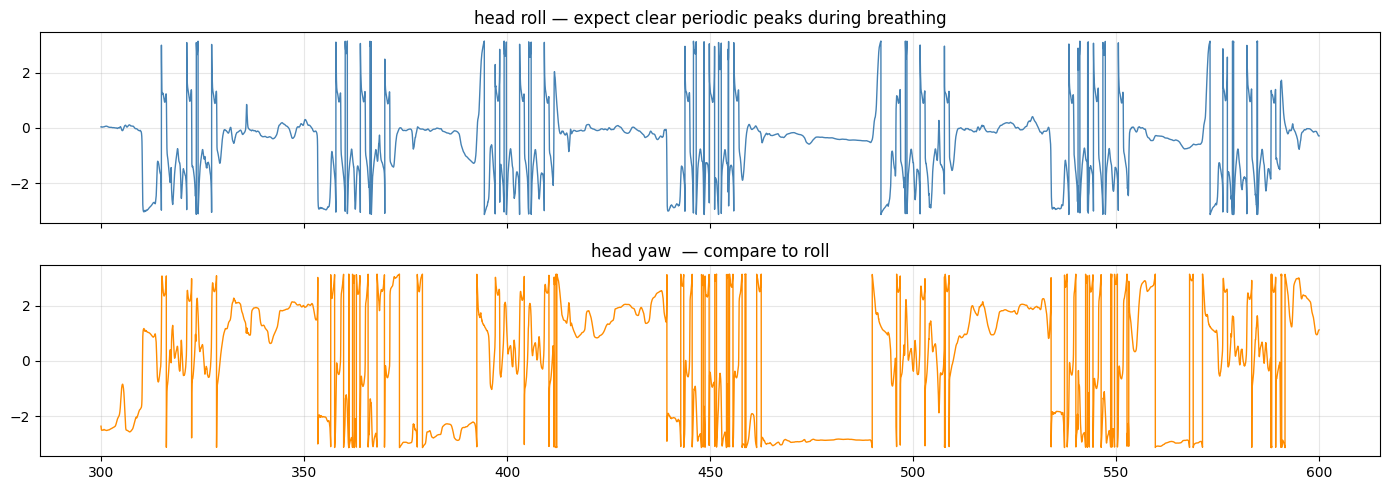

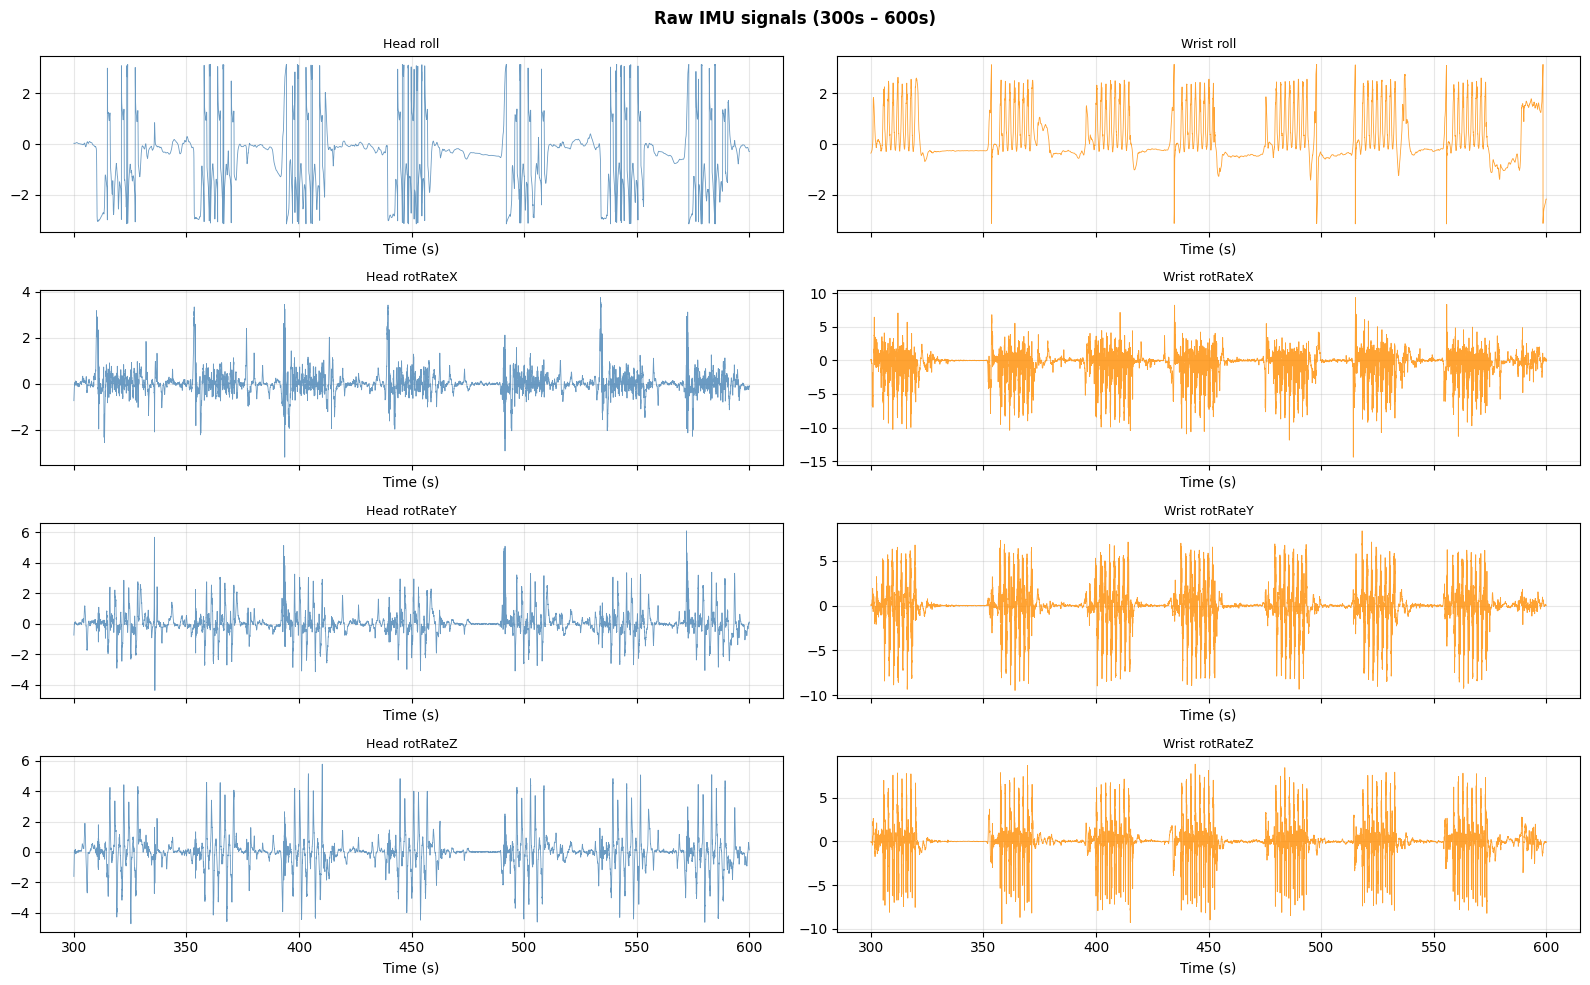

In [ ]:
# 设定你想看的时间范围（秒）
T_START = 300
T_END   = 600

# 截取这个时间段的数据
h_seg = head_raw[(head_raw["t_s"] >= T_START) & (head_raw["t_s"] <= T_END)]
w_seg = wrist_raw[(wrist_raw["t_s"] >= T_START) & (wrist_raw["t_s"] <= T_END)]

# ── 先看头部 roll vs yaw，确认哪个轴捕捉了呼吸 ──
fig, (a1, a2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
a1.plot(h_seg["t_s"], h_seg["roll"], color="steelblue",  lw=1.0)
a2.plot(h_seg["t_s"], h_seg["yaw"],  color="darkorange", lw=1.0)
a1.set_title("head roll — expect clear periodic peaks during breathing")
a2.set_title("head yaw  — compare to roll")
a1.grid(True, alpha=0.3); a2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 再看全部8个通道 ──
panels = [
    ("Head roll",     h_seg, "roll",          "steelblue"),
    ("Wrist roll",    w_seg, "roll",          "darkorange"),
    ("Head rotRateX", h_seg, "rotationRateX", "steelblue"),
    ("Wrist rotRateX",w_seg, "rotationRateX", "darkorange"),
    ("Head rotRateY", h_seg, "rotationRateY", "steelblue"),
    ("Wrist rotRateY",w_seg, "rotationRateY", "darkorange"),
    ("Head rotRateZ", h_seg, "rotationRateZ", "steelblue"),
    ("Wrist rotRateZ",w_seg, "rotationRateZ", "darkorange"),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex="col")
fig.suptitle(f"Raw IMU signals ({T_START}s – {T_END}s)", fontsize=12, fontweight="bold")

for ax, (title, df_, col, color) in zip(axes.flat, panels):
    ax.plot(df_["t_s"], df_[col], color=color, lw=0.6, alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5 — Resample to Uniform 50 Hz Grid

Apple Watch samples at ~100 Hz but the timing is slightly irregular (9.9 ms, 10.1 ms...).
We need a perfectly regular grid for filtering and peak detection to work correctly.
We also find the overlapping time window where both sensors were recording simultaneously.

**Why 50 Hz?** Swimming signals of interest are all below 5 Hz (breathing ~0.3 Hz, strokes ~0.5 Hz).
50 Hz gives 10x oversampling which is more than enough — and cuts file size in half.

In [ ]:
FS = 50

t_start = max(head_raw["t_abs"].iloc[0],  wrist_raw["t_abs"].iloc[0])
t_end   = min(head_raw["t_abs"].iloc[-1], wrist_raw["t_abs"].iloc[-1])
print(f"Overlap window: {t_end-t_start:.1f}s ({(t_end-t_start)/60:.1f} min)")

t_grid = np.arange(t_start, t_end, 1/FS)
t_rel  = t_grid - t_start

def resamp(df_, col):
    return np.interp(t_grid, df_["t_abs"].values, df_[col].values)

D = pd.DataFrame({
    "t":      t_rel,
    "h_roll":  np.degrees(resamp(head_raw,  "roll")),
    "h_rx":    resamp(head_raw,  "rotationRateX"),
    "h_ry":    resamp(head_raw,  "rotationRateY"),
    "h_rz":    resamp(head_raw,  "rotationRateZ"),
    "h_gx":    resamp(head_raw,  "gravityX"),
    "h_ax":    resamp(head_raw,  "accelerationX"),
    "h_ay":    resamp(head_raw,  "accelerationY"),
    "h_az":    resamp(head_raw,  "accelerationZ"),
    "w_roll":  np.degrees(resamp(wrist_raw, "roll")),
    "w_rx":    resamp(wrist_raw, "rotationRateX"),
    "w_ry":    resamp(wrist_raw, "rotationRateY"),
    "w_rz":    resamp(wrist_raw, "rotationRateZ"),
    "w_ax":    resamp(wrist_raw, "accelerationX"),
    "w_ay":    resamp(wrist_raw, "accelerationY"),
    "w_az":    resamp(wrist_raw, "accelerationZ"),
})
print(f"Resampled: {len(D):,} samples at {FS} Hz")
print(D.describe().round(3))


Overlap window: 1209.2s (20.2 min)
Resampled: 60,461 samples at 50 Hz
               t     h_roll       h_rx       h_ry       h_rz       h_gx  \
count  60461.000  60461.000  60461.000  60461.000  60461.000  60461.000   
mean     604.599    -34.201      0.025      0.014     -0.015     -0.102   
std      349.074     69.611      0.464      0.776      1.044      0.281   
min        0.000   -179.796     -4.905     -7.314     -6.428     -0.924   
25%      302.300    -72.946     -0.145     -0.213     -0.198     -0.216   
50%      604.599    -19.315     -0.002     -0.007      0.003     -0.119   
75%      906.899     -1.235      0.159      0.178      0.183     -0.011   
max     1209.199    179.959      3.915      7.432      5.755      0.994   

            h_ax       h_ay       h_az     w_roll       w_rx       w_ry  \
count  60461.000  60461.000  60461.000  60461.000  60461.000  60461.000   
mean      -0.005     -0.003      0.020     -1.611     -0.442     -0.069   
std        0.101      0.113  

## Step 6 — Full Session Overview

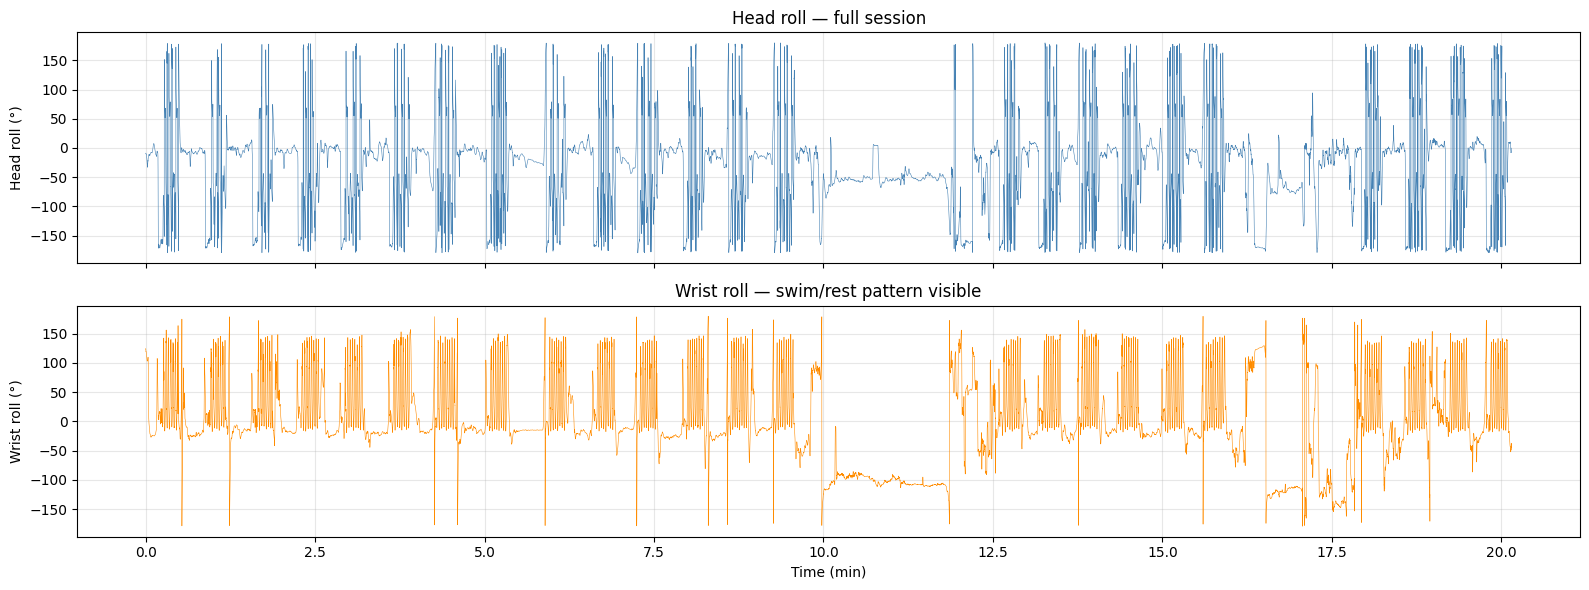

In [ ]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
a1.plot(D["t"]/60, D["h_roll"], color="steelblue",  lw=0.4)
a1.set_ylabel("Head roll (°)"); a1.set_title("Head roll — full session"); a1.grid(True, alpha=0.3)
a2.plot(D["t"]/60, D["w_roll"], color="darkorange", lw=0.4)
a2.set_ylabel("Wrist roll (°)"); a2.set_xlabel("Time (min)"); a2.set_title("Wrist roll — swim/rest pattern visible"); a2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# find when sustained swimming starts
w1 = int(1 * FS)
stds_1s = np.array([D["w_roll"].values[i:i+w1].std()
                    for i in range(0, len(D)-w1, w1)])
t_1s = np.arange(len(stds_1s))

print("Activity timeline (first 300s after trim):")
print(f"{'t':>5}  {'std':>6}  state")
for i, (t, sd) in enumerate(zip(t_1s, stds_1s)):
    if t > 300: break
    state = "SWIM" if sd > 15 else "rest"
    bar = "█" * int(sd / 5)
    print(f"{t:5d}s  {sd:5.1f}°  {state}  {bar[:25]}")

Activity timeline (first 300s after trim):
    t     std  state
    0s    4.1°  rest  
    1s    1.6°  rest  
    2s   45.0°  SWIM  ████████
    3s    5.9°  rest  █
    4s    1.8°  rest  
    5s    0.7°  rest  
    6s    0.2°  rest  
    7s    0.3°  rest  
    8s    1.1°  rest  
    9s   11.5°  rest  ██
   10s   25.0°  SWIM  █████
   11s    4.0°  rest  
   12s    2.0°  rest  
   13s    9.0°  rest  █
   14s    9.2°  rest  █
   15s   45.4°  SWIM  █████████
   16s   51.7°  SWIM  ██████████
   17s   46.1°  SWIM  █████████
   18s   57.7°  SWIM  ███████████
   19s   44.1°  SWIM  ████████
   20s   50.1°  SWIM  ██████████
   21s   37.2°  SWIM  ███████
   22s   51.4°  SWIM  ██████████
   23s   27.4°  SWIM  █████
   24s   44.1°  SWIM  ████████
   25s   23.7°  SWIM  ████
   26s   45.8°  SWIM  █████████
   27s   17.7°  SWIM  ███
   28s   43.1°  SWIM  ████████
   29s   11.0°  rest  ██
   30s    7.6°  rest  █
   31s   24.9°  SWIM  ████
   32s   96.0°  SWIM  ███████████████████
   33s   25.3°  SWIM  

## Step 7 — Why Single Axis Is Not Enough (Sensor Fusion)

Using only  misses information because the arm moves in 3D:
- **Entry/catch**: forward reach + internal rotation → mostly X
- **Pull**: internal rotation + wrist flexion → X + Y both active
- **Recovery**: external rotation + elevation → Y and Z dominate

Single axis catches some strokes but misses others depending on arm orientation at that moment.

**Fused signals we will compare:**

| Signal | Formula | Why |
|--------|---------|-----|
| Rotation magnitude | √(rx²+ry²+rz²) | Total angular speed — direction-agnostic |
| Acceleration magnitude | √(ax²+ay²+az²) | Total linear force — different physics |
| Band-passed versions | Butterworth 0.3–2 Hz | Remove drift + high-freq noise |
| Composite score | 0.5×rot_mag_bp + 0.5×acc_mag_bp | Fuse two independent signals |

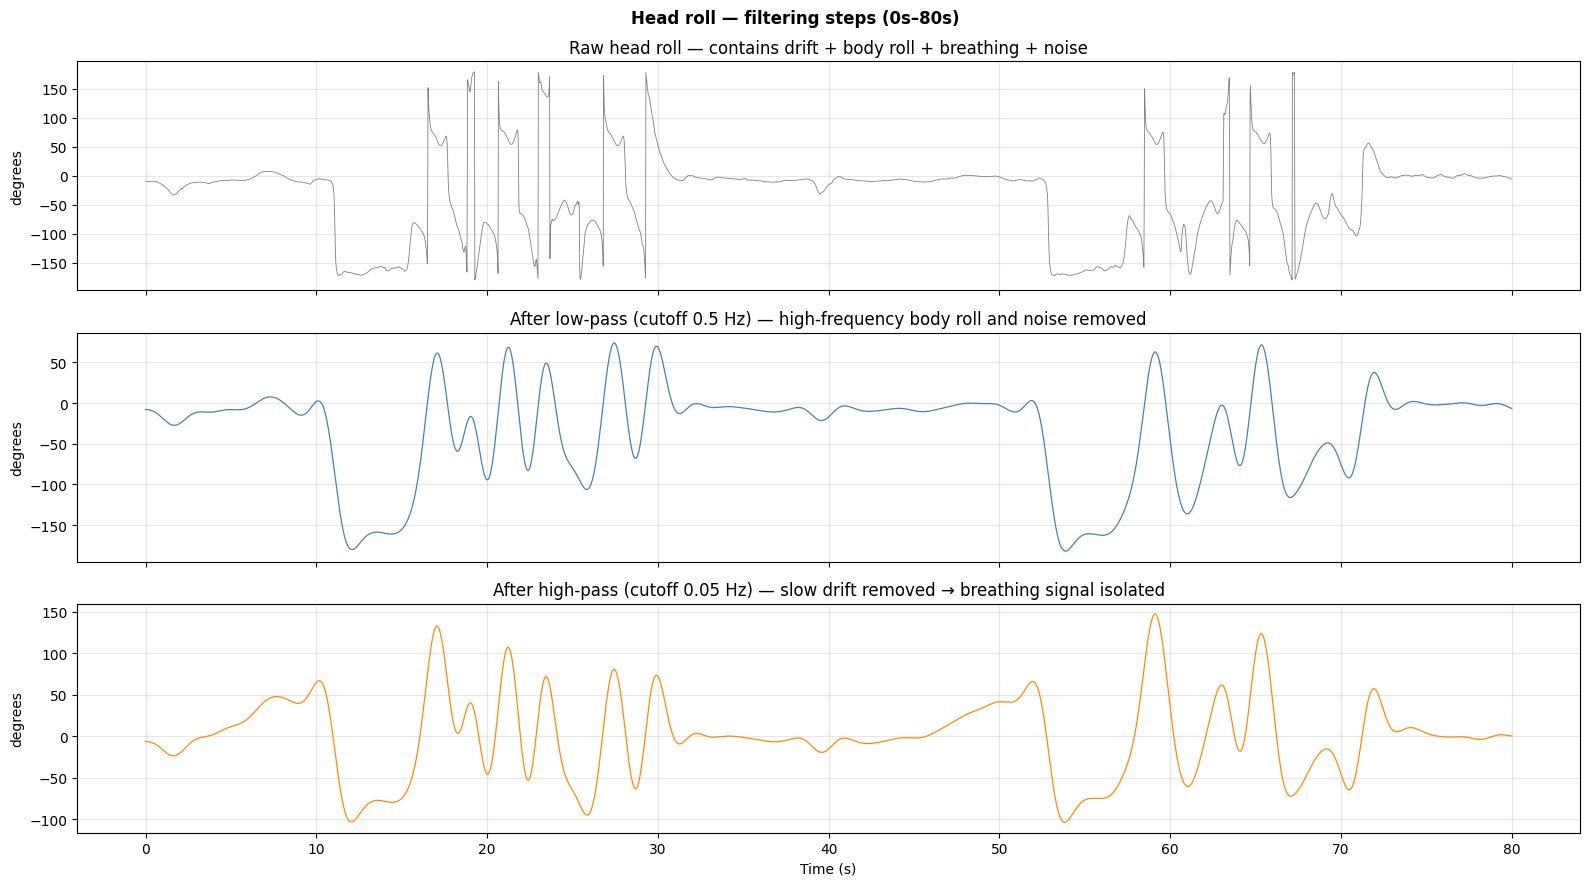

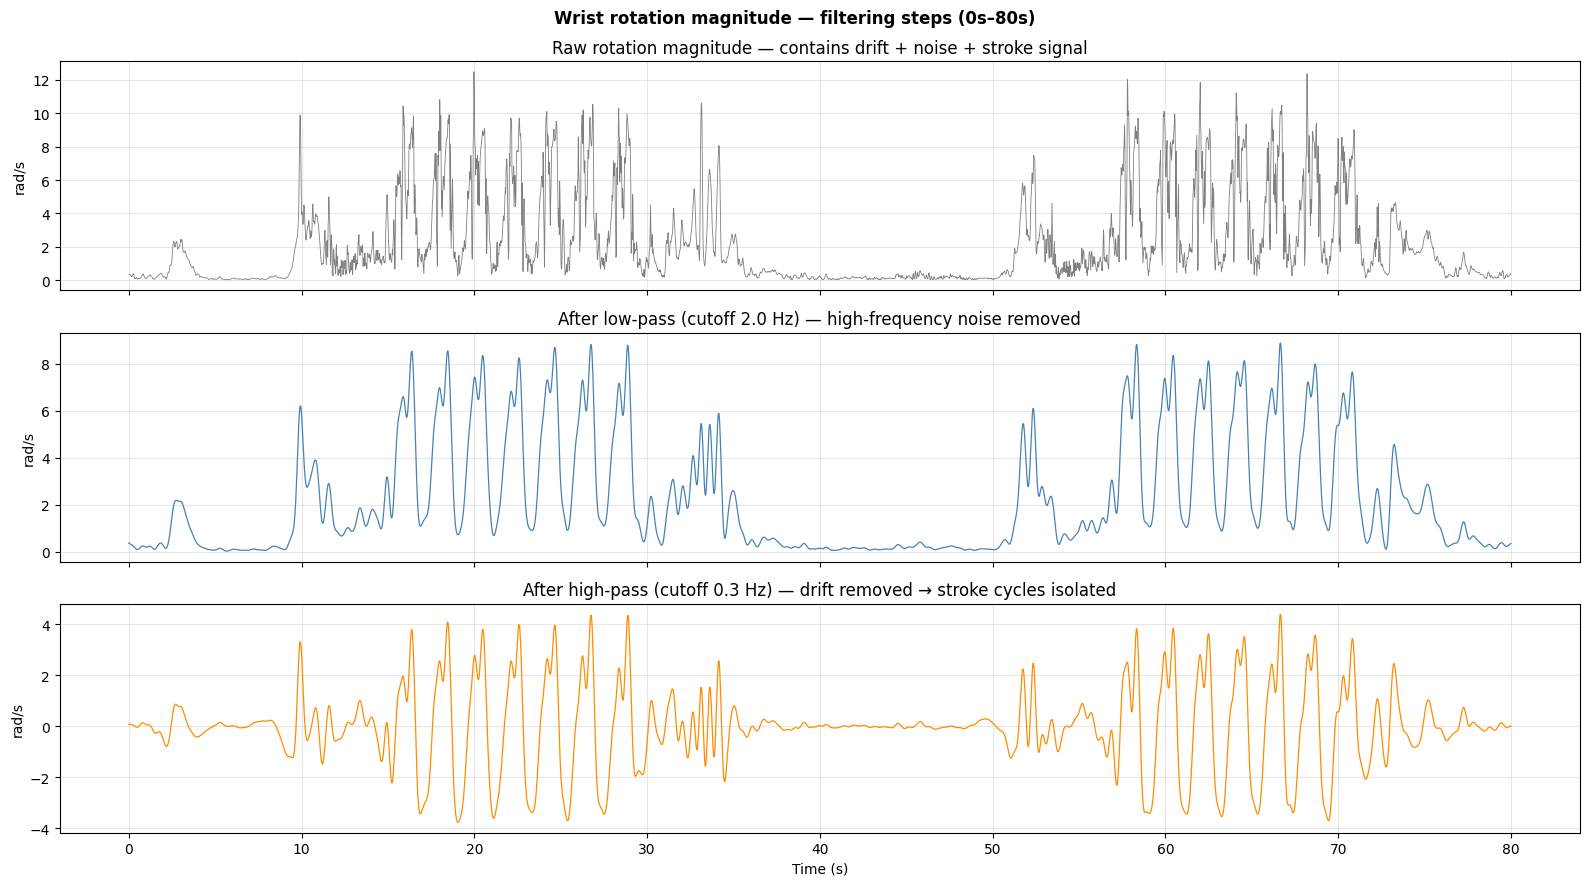

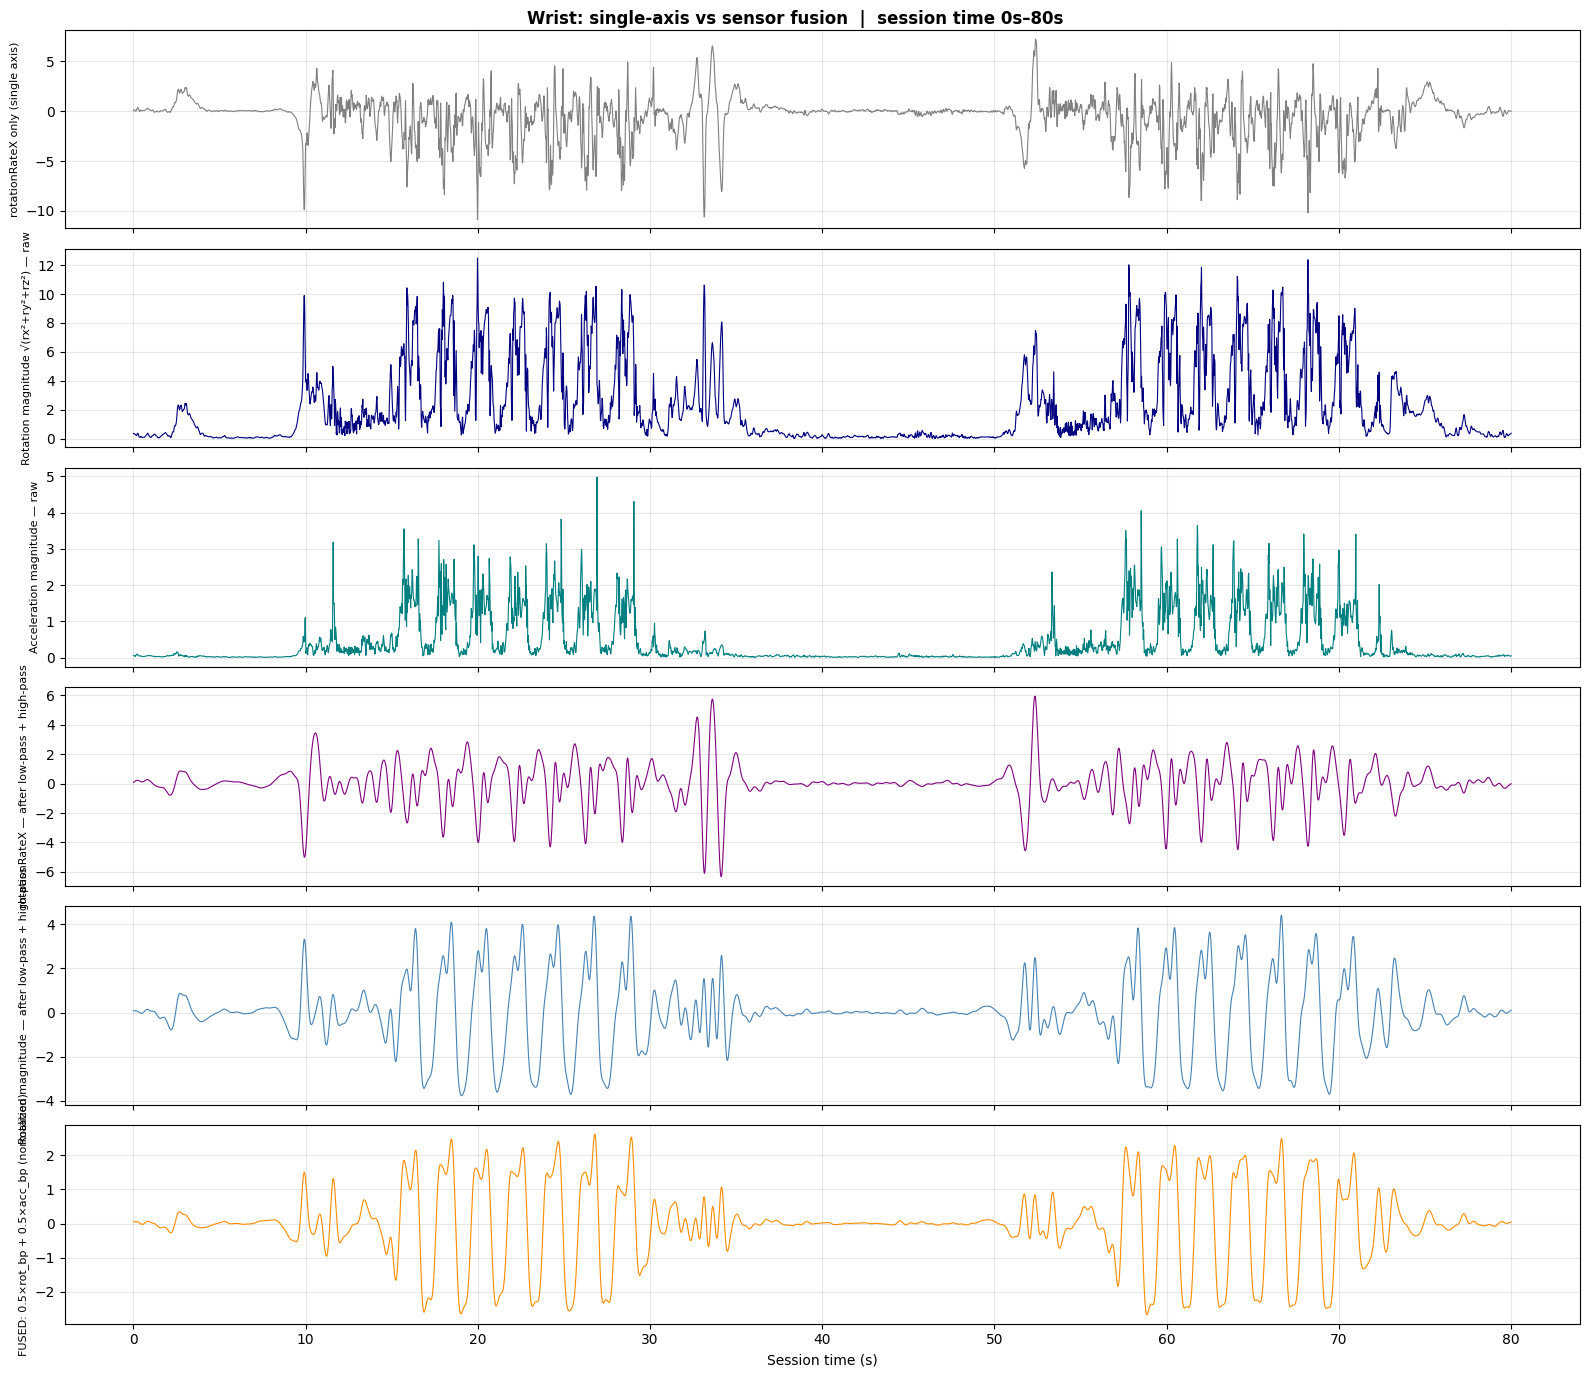

Filter design summary:
  Head roll   — low-pass 0.5 Hz → high-pass 0.05 Hz  (breathing band: 0.05–0.5 Hz)
  Wrist rot   — low-pass 2.0 Hz → high-pass 0.3  Hz  (stroke band:    0.3–2.0 Hz)
  Both use 4th-order Butterworth (zero-phase, sosfiltfilt)
  Fused stroke score = 0.5 × norm(rot_bp) + 0.5 × norm(acc_bp)


In [ ]:
# Step 7 — Sensor fusion and filtering

# ── filter functions (two-step: low-pass then high-pass) ──
def lowpass(x, cutoff, fs=FS):
    sos = sp.butter(4, cutoff, btype="low", fs=fs, output="sos")
    return sp.sosfiltfilt(sos, x)

def highpass(x, cutoff, fs=FS):
    sos = sp.butter(4, cutoff, btype="high", fs=fs, output="sos")
    return sp.sosfiltfilt(sos, x)

def bp(x, lo, hi, fs=FS):
    # equivalent to low-pass then high-pass
    return highpass(lowpass(x, hi, fs), lo, fs)

# ── compute fused signals ──
D["w_rot_mag"]  = np.sqrt(D["w_rx"]**2 + D["w_ry"]**2 + D["w_rz"]**2)
D["w_acc_mag"]  = np.sqrt(D["w_ax"]**2 + D["w_ay"]**2 + D["w_az"]**2)

# head roll: breathing band (0.05–0.5 Hz)
D["h_roll_bp"]  = bp(D["h_roll"].values,    0.05, 0.5)

# wrist: stroke band (0.3–2.0 Hz)
D["w_rx_bp"]    = bp(D["w_rx"].values,      0.3,  2.0)
D["w_rot_bp"]   = bp(D["w_rot_mag"].values, 0.3,  2.0)
D["w_acc_bp"]   = bp(D["w_acc_mag"].values, 0.3,  2.0)

def norm(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x - x.mean()

D["w_stroke"] = 0.5 * norm(D["w_rot_bp"].values) + 0.5 * norm(D["w_acc_bp"].values)

# ── filtering visualization: head roll ──
t0, t1 = 0, 80
seg    = (D["t"] >= t0) & (D["t"] <= t1)
t_w    = D.loc[seg, "t"].values

h_raw    = D.loc[seg, "h_roll"].values
h_lp     = lowpass(D["h_roll"].values, 0.5)[seg.values]
h_lp_hp  = highpass(h_lp, 0.05)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle(f"Head roll — filtering steps ({t0}s–{t1}s)",
             fontsize=12, fontweight="bold")

axes[0].plot(t_w, h_raw,   color="gray",       lw=0.6)
axes[0].set_title("Raw head roll — contains drift + body roll + breathing + noise")
axes[0].set_ylabel("degrees"); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_w, h_lp,    color="steelblue",  lw=0.9)
axes[1].set_title("After low-pass (cutoff 0.5 Hz) — high-frequency body roll and noise removed")
axes[1].set_ylabel("degrees"); axes[1].grid(True, alpha=0.3)

axes[2].plot(t_w, h_lp_hp, color="darkorange", lw=0.9)
axes[2].set_title("After high-pass (cutoff 0.05 Hz) — slow drift removed → breathing signal isolated")
axes[2].set_ylabel("degrees"); axes[2].set_xlabel("Time (s)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── filtering visualization: wrist rotation magnitude ──
w_raw   = D.loc[seg, "w_rot_mag"].values
w_lp    = lowpass(D["w_rot_mag"].values, 2.0)[seg.values]
w_lp_hp = highpass(w_lp, 0.3)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle(f"Wrist rotation magnitude — filtering steps ({t0}s–{t1}s)",
             fontsize=12, fontweight="bold")

axes[0].plot(t_w, w_raw,   color="gray",       lw=0.6)
axes[0].set_title("Raw rotation magnitude — contains drift + noise + stroke signal")
axes[0].set_ylabel("rad/s"); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_w, w_lp,    color="steelblue",  lw=0.9)
axes[1].set_title("After low-pass (cutoff 2.0 Hz) — high-frequency noise removed")
axes[1].set_ylabel("rad/s"); axes[1].grid(True, alpha=0.3)

axes[2].plot(t_w, w_lp_hp, color="darkorange", lw=0.9)
axes[2].set_title("After high-pass (cutoff 0.3 Hz) — drift removed → stroke cycles isolated")
axes[2].set_ylabel("rad/s"); axes[2].set_xlabel("Time (s)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── sensor fusion comparison: single axis vs fused ──
t0_f, t1_f = 0, 80
seg_f  = (D["t"] >= t0_f) & (D["t"] <= t1_f)
t_w_f  = D.loc[seg_f, "t"].values

fig, axes = plt.subplots(6, 1, figsize=(16, 14), sharex=True)
fig.suptitle(f"Wrist: single-axis vs sensor fusion  |  session time {t0_f}s–{t1_f}s",
             fontsize=12, fontweight="bold")

for ax, (col, label, color) in zip(axes, [
    ("w_rx",      "rotationRateX only (single axis)",             "gray"),
    ("w_rot_mag", "Rotation magnitude √(rx²+ry²+rz²) — raw",     "navy"),
    ("w_acc_mag", "Acceleration magnitude — raw",                 "teal"),
    ("w_rx_bp",   "rotationRateX — after low-pass + high-pass",   "purple"),
    ("w_rot_bp",  "Rotation magnitude — after low-pass + high-pass", "steelblue"),
    ("w_stroke",  "FUSED: 0.5×rot_bp + 0.5×acc_bp (normalized)", "darkorange"),
]):
    ax.plot(t_w_f, D.loc[seg_f, col].values, color=color, lw=0.8)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Session time (s)")
plt.tight_layout(); plt.show()

print("Filter design summary:")
print("  Head roll   — low-pass 0.5 Hz → high-pass 0.05 Hz  (breathing band: 0.05–0.5 Hz)")
print("  Wrist rot   — low-pass 2.0 Hz → high-pass 0.3  Hz  (stroke band:    0.3–2.0 Hz)")
print("  Both use 4th-order Butterworth (zero-phase, sosfiltfilt)")
print("  Fused stroke score = 0.5 × norm(rot_bp) + 0.5 × norm(acc_bp)")

## Step 8 — Why Two-Step Filtering? Visualizing Frequency Components

Rather than applying a single band-pass filter, we use a two-step approach: low-pass first, then high-pass. The result is mathematically identical to band-pass, but each step has a clear, inspectable purpose.

**Step 1 — Low-pass filter** removes everything above the cutoff, keeping only slow signals:
- For stroke detection (cutoff 2.0 Hz): removes high-frequency noise, vibrations, and finger movements above 2 Hz
- For breathing detection (cutoff 0.5 Hz): removes body roll oscillations from each stroke (0.5–3 Hz), which look like breathing but are not

**Step 2 — High-pass filter** removes everything below the cutoff, keeping only fast signals:
- For stroke detection (cutoff 0.3 Hz): removes slow wrist drift and temperature effects below 0.3 Hz
- For breathing detection (cutoff 0.05 Hz): removes the watch slowly rotating in the cap over the session

**What remains after both steps:**
- Stroke band (0.3–2.0 Hz): freestyle stroke rate of 28–45 strokes/min = 0.47–0.75 Hz sits in this band
- Breathing band (0.05–0.5 Hz): breathing rate of 15–25 breaths/min = 0.25–0.42 Hz sits in this band

Both filters use a 4th-order Butterworth design with zero-phase processing (sosfiltfilt), which avoids any time shift in the filtered signal — important because we need accurate event timestamps for coordination analysis.

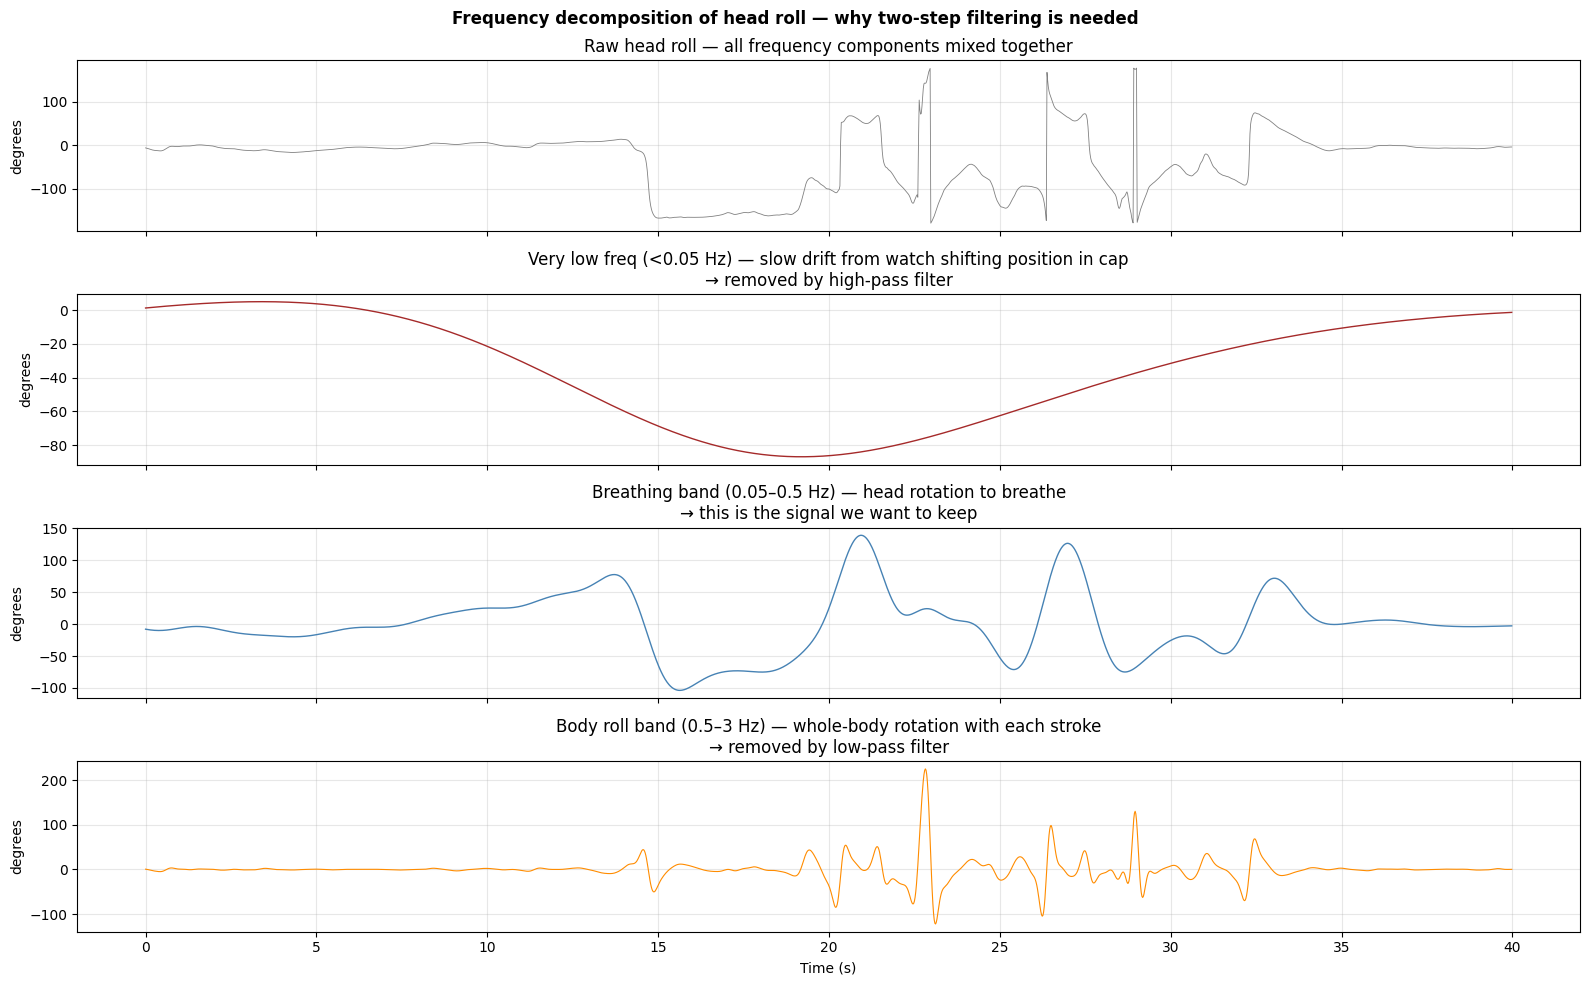

Key insight:
  Without low-pass: body roll oscillations would be mistaken for breathing
  Without high-pass: slow drift would shift the baseline and distort peak detection
  Two-step filtering isolates exactly the breathing frequency band


In [ ]:
# Step 8 — Visualizing frequency components of head roll
# this step shows WHY we apply the two-step filter:
# low-pass removes high-frequency body roll (0.5-3 Hz)
# high-pass removes low-frequency drift (<0.05 Hz)
# what remains is the breathing band (0.05-0.5 Hz)

t0, t1 = 80, 120
seg = (D["t"] >= t0) & (D["t"] <= t1)
t_w = D.loc[seg, "t"].values - D.loc[seg, "t"].values[0]
h_raw_seg = D.loc[seg, "h_roll"].values

# isolate each frequency component for visualization
h_drift     = lowpass(D["h_roll"].values, 0.05)[seg.values]        # <0.05 Hz: slow drift only
h_breathing = bp(D["h_roll"].values, 0.05, 0.5)[seg.values]        # 0.05-0.5 Hz: breathing only
h_bodyroll  = bp(D["h_roll"].values, 0.5,  3.0)[seg.values]        # 0.5-3 Hz: body roll only

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Frequency decomposition of head roll — why two-step filtering is needed",
             fontsize=12, fontweight="bold")

axes[0].plot(t_w, h_raw_seg, color="gray", lw=0.6)
axes[0].set_title("Raw head roll — all frequency components mixed together")
axes[0].set_ylabel("degrees"); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_w, h_drift, color="brown", lw=1.0)
axes[1].set_title("Very low freq (<0.05 Hz) — slow drift from watch shifting position in cap"
                  "\n→ removed by high-pass filter")
axes[1].set_ylabel("degrees"); axes[1].grid(True, alpha=0.3)

axes[2].plot(t_w, h_breathing, color="steelblue", lw=1.0)
axes[2].set_title("Breathing band (0.05–0.5 Hz) — head rotation to breathe"
                  "\n→ this is the signal we want to keep")
axes[2].set_ylabel("degrees"); axes[2].grid(True, alpha=0.3)

axes[3].plot(t_w, h_bodyroll, color="darkorange", lw=0.8)
axes[3].set_title("Body roll band (0.5–3 Hz) — whole-body rotation with each stroke"
                  "\n→ removed by low-pass filter")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("degrees"); axes[3].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("Key insight:")
print("  Without low-pass: body roll oscillations would be mistaken for breathing")
print("  Without high-pass: slow drift would shift the baseline and distort peak detection")
print("  Two-step filtering isolates exactly the breathing frequency band")

## Step 9 — Activity Detection: Swimming vs Rest

Before detecting strokes or breaths, we need to know *when* the participant is swimming.
We compute a peak-to-peak amplitude of wrist roll in 1-second windows.

- **Swimming**: wrist oscillates rhythmically → std ≈ 20–80°
- **Resting at wall**: arm mostly still → std < 5°

Detected 23 swim segments:
  Lap 1: 9s – 35s (26s)
  Lap 2: 51s – 76s (25s)
  Lap 3: 93s – 121s (28s)
  Lap 4: 133s – 160s (27s)
  Lap 5: 171s – 195s (24s)
  Lap 6: 214s – 243s (29s)
  Lap 7: 254s – 280s (26s)
  Lap 8: 300s – 324s (24s)
  Lap 9: 352s – 380s (28s)
  Lap 10: 395s – 419s (24s)
  Lap 11: 432s – 456s (24s)
  Lap 12: 474s – 499s (25s)
  Lap 13: 514s – 540s (26s)
  Lap 14: 554s – 580s (26s)
  Lap 15: 710s – 781s (71s)
  Lap 16: 789s – 811s (22s)
  Lap 17: 824s – 850s (26s)
  Lap 18: 859s – 883s (24s)
  Lap 19: 899s – 923s (24s)
  Lap 20: 934s – 982s (48s)
  Lap 21: 1023s – 1039s (16s)
  Lap 22: 1062s – 1179s (117s)
  Lap 23: 1184s – 1209s (25s)


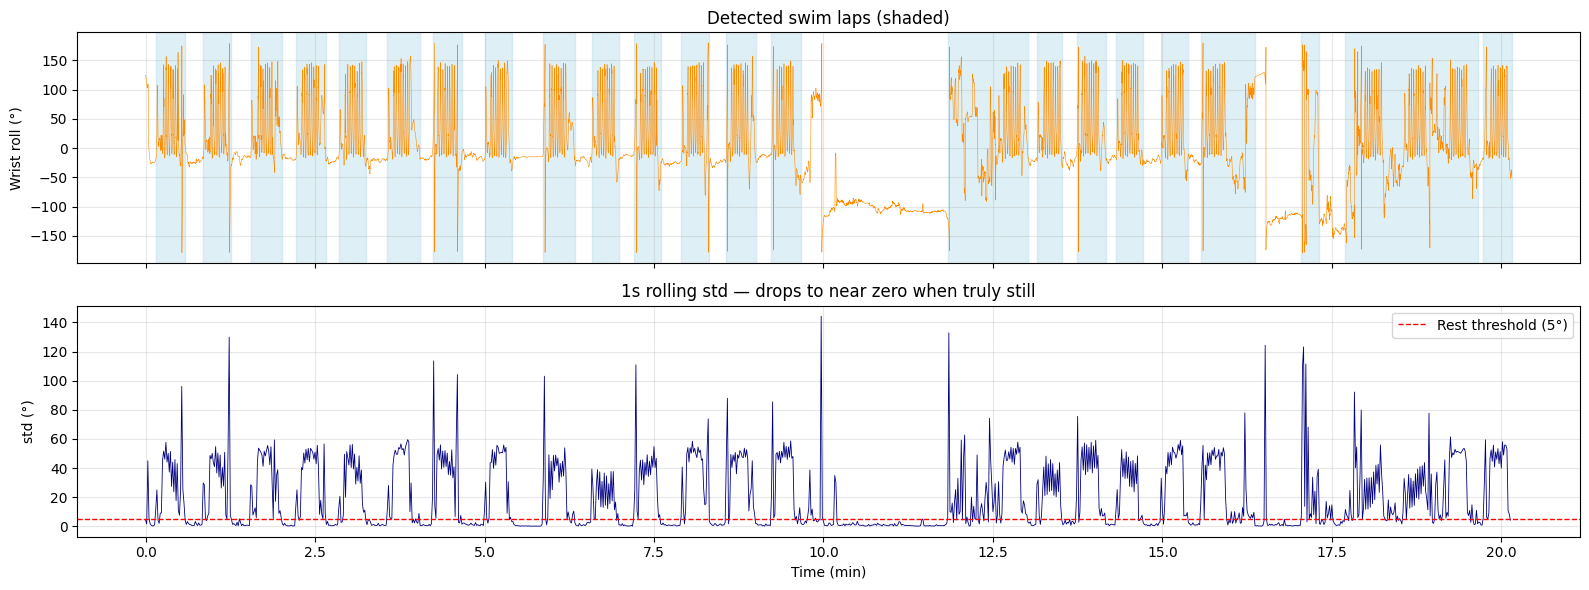

In [ ]:
# Step 9 — Activity Detection: Swimming vs Rest

w1 = int(1 * FS)
stds_1s = np.array([D["w_roll"].values[i:i+w1].std()
                    for i in range(0, len(D)-w1, w1)])
is_rest = stds_1s < 5.0

# find contiguous rest blocks
changes  = np.diff(is_rest.astype(int))
r_starts = np.concatenate([[0] if is_rest[0] else [],
                            np.where(changes == 1)[0] + 1])
r_ends   = np.concatenate([np.where(changes == -1)[0] + 1,
                            [len(is_rest)] if is_rest[-1] else []])

# genuine rest = at least 5s consecutive near-zero activity
rests = [(int(s), int(e)) for s, e in zip(r_starts, r_ends) if (e - s) >= 5]

# build swim laps from gaps between rest periods
swim_segs = []
prev = 0
for rs, re in rests:
    dur = rs - prev
    if dur >= 16:
        swim_segs.append({
            "start_s": float(D["t"].iloc[int(prev * w1)]),
            "end_s":   float(D["t"].iloc[min(int(rs * w1), len(D) - 1)]),
            "dur_s":   float(dur)
        })
    prev = re
if prev * w1 < len(D):
    dur = len(stds_1s) - prev
    if dur >= 16:
        swim_segs.append({
            "start_s": float(D["t"].iloc[int(prev * w1)]),
            "end_s":   float(D["t"].iloc[-1]),
            "dur_s":   float(dur)
        })

print(f"Detected {len(swim_segs)} swim segments:")
for i, s in enumerate(swim_segs):
    print(f"  Lap {i+1}: {s['start_s']:.0f}s – {s['end_s']:.0f}s ({s['dur_s']:.0f}s)")

# plot
fig, (a1, a2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

a1.plot(D["t"] / 60, D["w_roll"], color="darkorange", lw=0.4)
for s in swim_segs:
    a1.axvspan(s["start_s"] / 60, s["end_s"] / 60, color="lightblue", alpha=0.4)
a1.set_title("Detected swim laps (shaded)")
a1.set_ylabel("Wrist roll (°)")
a1.grid(True, alpha=0.3)

t_1s = np.arange(len(stds_1s)) / 60
a2.plot(t_1s, stds_1s, color="navy", lw=0.6)
a2.axhline(5.0, color="red", lw=1, ls="--", label="Rest threshold (5°)")
a2.set_title("1s rolling std — drops to near zero when truly still")
a2.set_ylabel("std (°)")
a2.set_xlabel("Time (min)")
a2.legend()
a2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10 — Stroke Cycle Detection

We detect peaks in the fused stroke signal (band-passed rotation magnitude + acceleration magnitude).

**Peak detection parameters:**
- : minimum samples between two peaks → sets maximum stroke rate
- : how much the peak must stand out from surrounding signal → filters noise

We also compare single-axis vs fused to show why your advisor is right.

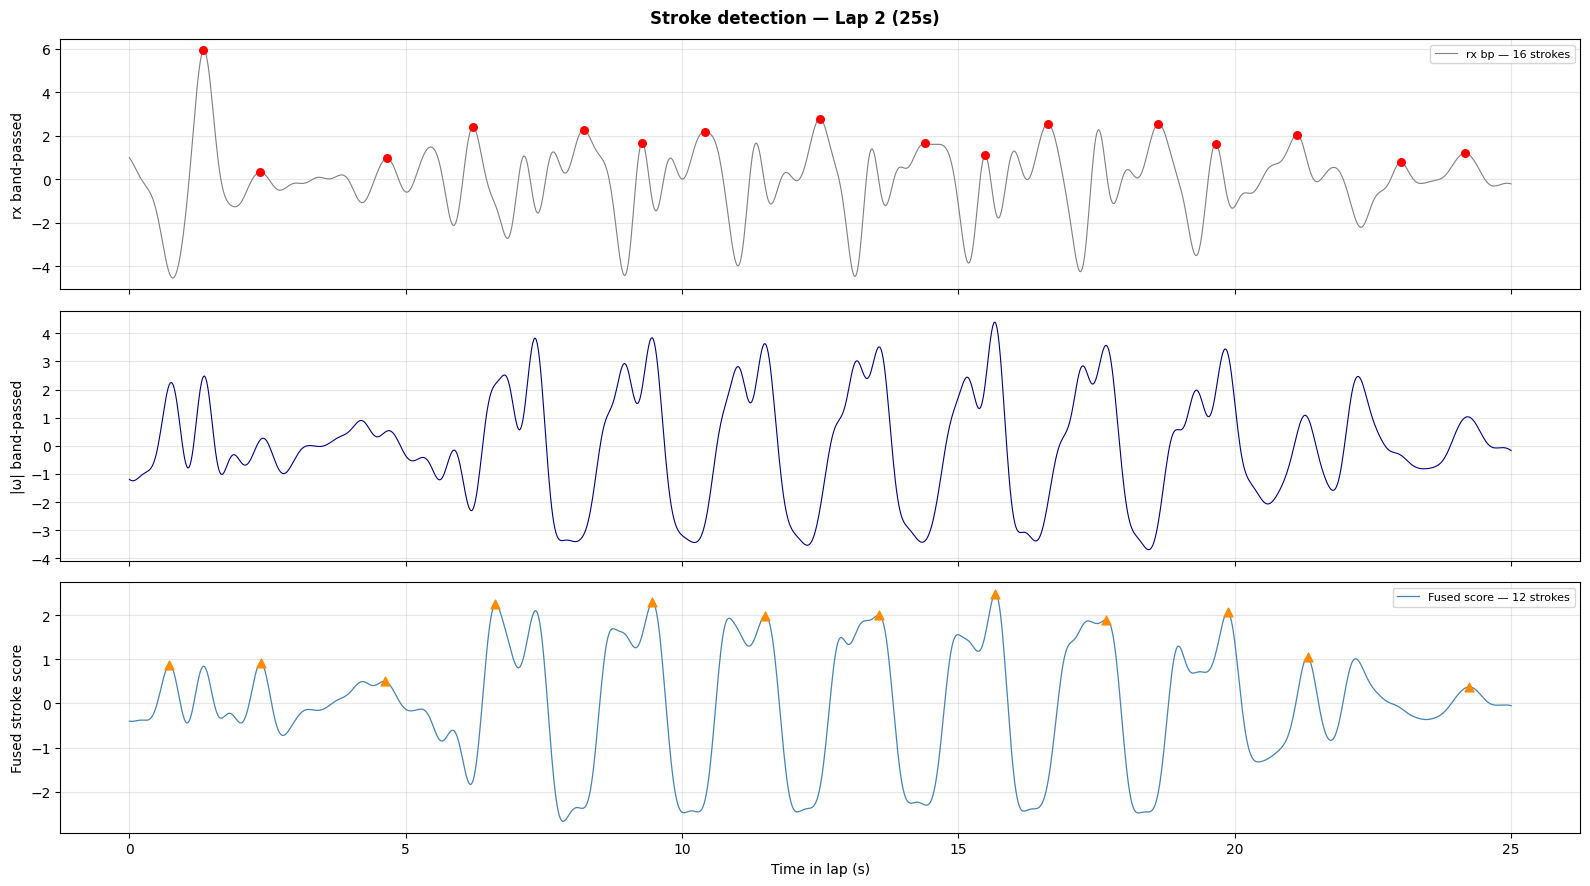

Fused : 12 strokes, 28.8/min, IBI=2.14±0.41s
Single: 16 strokes, 38.4/min, IBI=1.52±0.44s


In [ ]:
MIN_STR_IBI = 1.0  # seconds

stroke_idx, _ = sp.find_peaks(D["w_stroke"].values, distance=int(MIN_STR_IBI*FS), prominence=0.5)
stroke_idx_rx, _ = sp.find_peaks(D["w_rx_bp"].values, distance=int(MIN_STR_IBI*FS), prominence=0.5)

# Show one full lap
if len(swim_segs) > 1:
    lap = swim_segs[1]
else:
    lap = swim_segs[0]
mask = (D["t"] >= lap["start_s"]) & (D["t"] <= lap["end_s"])
t_l  = D.loc[mask, "t"].values - lap["start_s"]

si_f  = [i for i in stroke_idx    if lap["start_s"] <= D["t"].iloc[i] <= lap["end_s"]]
si_rx = [i for i in stroke_idx_rx if lap["start_s"] <= D["t"].iloc[i] <= lap["end_s"]]
tf    = [D["t"].iloc[i]-lap["start_s"] for i in si_f]
trx   = [D["t"].iloc[i]-lap["start_s"] for i in si_rx]

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle(f"Stroke detection — Lap {swim_segs.index(lap)+1} ({lap["dur_s"]:.0f}s)", fontsize=12, fontweight="bold")

v_rx  = D.loc[mask, "w_rx_bp"].values
v_rot = D.loc[mask, "w_rot_bp"].values
v_str = D.loc[mask, "w_stroke"].values

axes[0].plot(t_l, v_rx,  color="gray",       lw=0.8, label=f"rx bp — {len(trx)} strokes")
axes[0].scatter(trx, [v_rx[np.argmin(np.abs(t_l-ti))] for ti in trx], color="red", s=30, zorder=5)
axes[0].set_ylabel("rx band-passed"); axes[0].legend(fontsize=8)

axes[1].plot(t_l, v_rot, color="navy",       lw=0.8, label="Rotation magnitude bp")
axes[1].set_ylabel("|ω| band-passed")

axes[2].plot(t_l, v_str, color="steelblue",  lw=0.9, label=f"Fused score — {len(tf)} strokes")
axes[2].scatter(tf,  [v_str[np.argmin(np.abs(t_l-ti))] for ti in tf],  color="darkorange", s=40, marker="^", zorder=5)
axes[2].set_ylabel("Fused stroke score"); axes[2].set_xlabel("Time in lap (s)"); axes[2].legend(fontsize=8)

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

if len(tf) > 1:
    ibis = np.diff(tf)
    print(f"Fused : {len(tf)} strokes, {len(tf)/(lap["dur_s"]/60):.1f}/min, IBI={ibis.mean():.2f}±{ibis.std():.2f}s")
if len(trx) > 1:
    ibis = np.diff(trx)
    print(f"Single: {len(trx)} strokes, {len(trx)/(lap["dur_s"]/60):.1f}/min, IBI={ibis.mean():.2f}±{ibis.std():.2f}s")


## Step 11 — Breathing Event Detection

Detect when the participant rotates their head to breathe.

**Set BREATH_SIDE to match your participant:**
-  → look for positive peaks in head roll (head turns right)
-  → look for negative peaks (head turns left)
-  → detect peaks on both sides

Positive peaks (prominence):
  t=1.0s  prominence=22.8°  roll=66.1°
  t=4.5s  prominence=0.2°  roll=-74.0°
  t=8.1s  prominence=222.2°  roll=147.3°
  t=14.3s  prominence=182.0°  roll=121.0°
  t=20.9s  prominence=52.6°  roll=59.3°
Negative peaks (prominence):
  t=2.8s  prominence=169.2°  roll=-103.1°
  t=10.0s  prominence=182.0°  roll=-61.0°
  t=16.1s  prominence=134.2°  roll=-74.8°
  t=19.5s  prominence=47.9°  roll=-64.9°


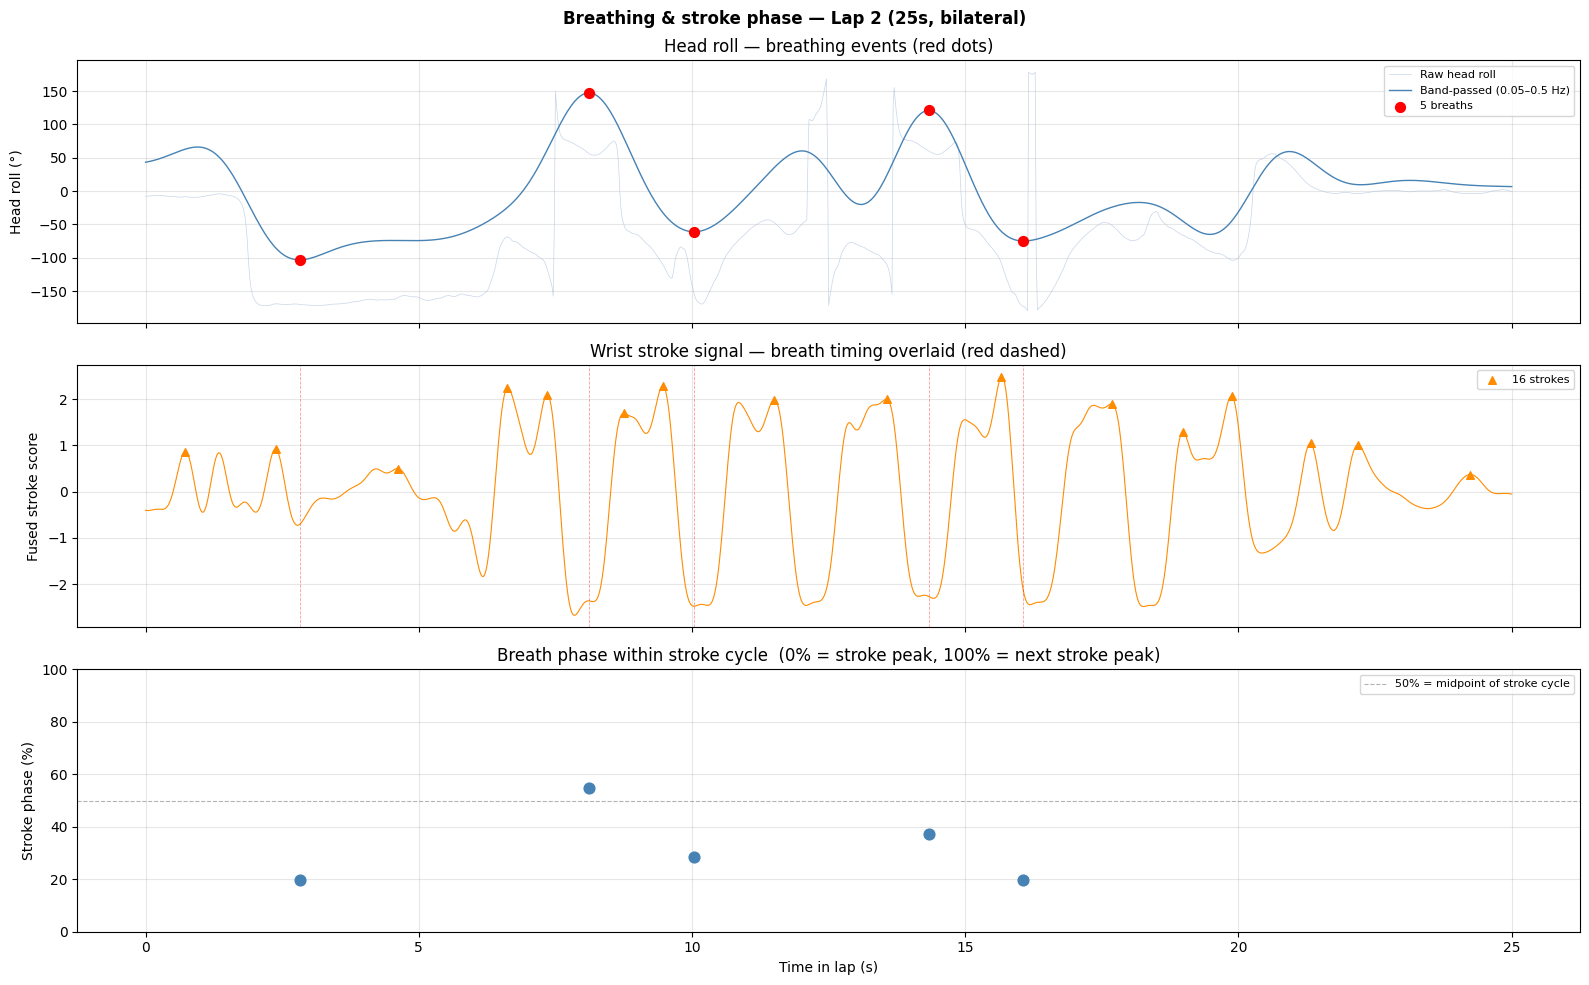

All stroke peaks (prominence):
  t=0.7s  prominence=1.274  score=0.866
  t=2.4s  prominence=1.368  score=0.923
  t=3.2s  prominence=0.021  score=-0.138
  t=4.6s  prominence=1.229  score=0.502
  t=5.8s  prominence=0.245  score=-0.610
  t=6.6s  prominence=4.077  score=2.241
  t=7.3s  prominence=1.293  score=2.098
  t=8.8s  prominence=0.433  score=1.693
  t=9.5s  prominence=4.764  score=2.287
  t=10.2s  prominence=0.023  score=-2.436
  t=11.5s  prominence=4.447  score=1.987
  t=13.6s  prominence=4.306  score=1.999
  t=14.3s  prominence=0.023  score=-2.239
  t=15.7s  prominence=4.969  score=2.486
  t=17.7s  prominence=4.341  score=1.897
  t=19.0s  prominence=0.612  score=1.298
  t=19.9s  prominence=3.391  score=2.064
  t=21.3s  prominence=1.881  score=1.043
  t=22.2s  prominence=1.378  score=1.012
  t=24.2s  prominence=0.423  score=0.372


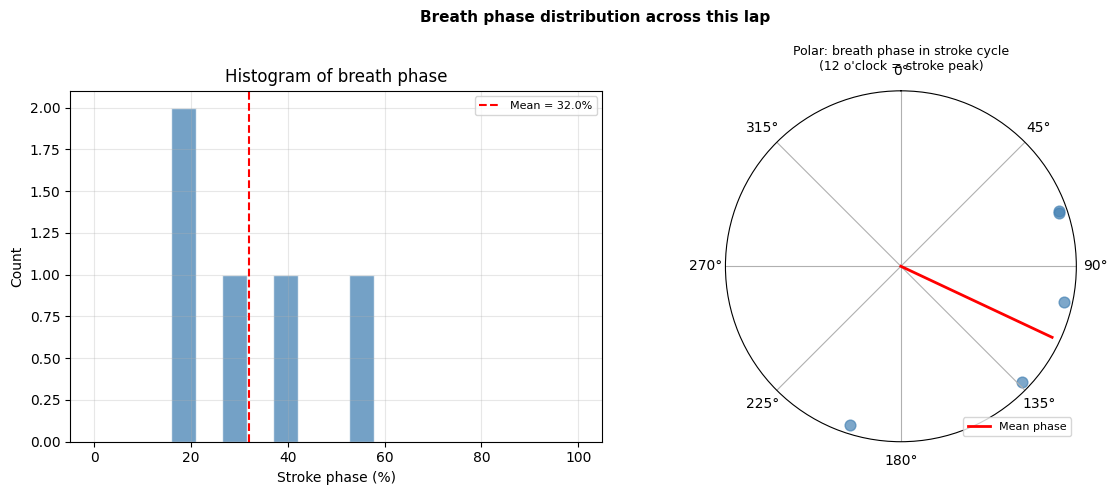


=== Lap 2 summary ===
Duration      : 25s
Breaths       : 5  (12.0/min)
Strokes       : 16  (38.4/min)
Cycles/breath : 3.20

Breath phase in stroke cycle:
  Mean  : 32.0%
  Std   : 13.2%  ← consistency (lower = better coordination)
  Median: 28.4%

Breath lag after nearest stroke peak:
  Mean  : 0.60s
  Std   : 0.16s


In [ ]:
# Step 11 — Breathing detection + stroke phase analysis

BREATH_SIDE = "bilateral"
# also increase minimum interval between breaths
# 25s lap with 5 breaths = one breath every 5s minimum
MIN_BR_IBI  = 3.0
# increase prominence to filter out body roll artifacts
# start at 15.0 and increase until breath count is ~5 per lap
BR_PROM_DEG = 120.0
MIN_STR_IBI = 0.7

# use second lap as example — change index to inspect different laps
lap = swim_segs[1] if len(swim_segs) > 1 else swim_segs[0]
mask    = (D["t"] >= lap["start_s"]) & (D["t"] <= lap["end_s"])
t_l     = D.loc[mask, "t"].values - lap["start_s"]
roll_bp = D.loc[mask, "h_roll_bp"].values
stroke  = D.loc[mask, "w_stroke"].values

# detect breaths
if BREATH_SIDE == "right":
    bi, _ = sp.find_peaks( roll_bp, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
elif BREATH_SIDE == "left":
    bi, _ = sp.find_peaks(-roll_bp, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
else:
    pos, _ = sp.find_peaks( roll_bp, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
    neg, _ = sp.find_peaks(-roll_bp, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
    bi = np.sort(np.concatenate([pos, neg]))

# check prominence of each detected breath
if BREATH_SIDE == "bilateral":
    pos, pos_props = sp.find_peaks( roll_bp, distance=int(MIN_BR_IBI*FS), prominence=0)
    neg, neg_props = sp.find_peaks(-roll_bp, distance=int(MIN_BR_IBI*FS), prominence=0)
    print("Positive peaks (prominence):")
    for i, p in zip(pos, pos_props["prominences"]):
        print(f"  t={t_l[i]:.1f}s  prominence={p:.1f}°  roll={roll_bp[i]:.1f}°")
    print("Negative peaks (prominence):")
    for i, p in zip(neg, neg_props["prominences"]):
        print(f"  t={t_l[i]:.1f}s  prominence={p:.1f}°  roll={roll_bp[i]:.1f}°")
# detect strokes
si, _ = sp.find_peaks(stroke, distance=int(MIN_STR_IBI*FS), prominence=0.3)
# filter out negative-score peaks (these are valleys, not real strokes)
si = si[stroke[si] > 0]

bt = t_l[bi]  # breath timestamps
st = t_l[si]  # stroke timestamps

# compute stroke phase for each breath
# phase = (t_breath - t_prev_stroke) / (t_next_stroke - t_prev_stroke) * 100
phases = []
lags   = []
for b in bt:
    prev_strokes = st[st < b]
    next_strokes = st[st > b]
    if len(prev_strokes) == 0 or len(next_strokes) == 0:
        continue
    t_prev = prev_strokes[-1]
    t_next = next_strokes[0]
    cycle_dur = t_next - t_prev
    phase = (b - t_prev) / cycle_dur * 100  # 0-100%
    lag   = b - t_prev  # seconds after previous stroke peak
    phases.append(phase)
    lags.append(lag)

phases = np.array(phases)
lags   = np.array(lags)

# ── Plot 1: breath detection + stroke markers ──
fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f"Breathing & stroke phase — Lap {swim_segs.index(lap)+1} "
             f"({lap['dur_s']:.0f}s, {BREATH_SIDE})", fontsize=12, fontweight="bold")

a1.plot(t_l, D.loc[mask, "h_roll"].values, color="lightsteelblue", lw=0.5, alpha=0.7, label="Raw head roll")
a1.plot(t_l, roll_bp, color="steelblue", lw=1.0, label="Band-passed (0.05–0.5 Hz)")
a1.scatter(bt, roll_bp[bi], color="red", s=50, zorder=5, label=f"{len(bi)} breaths")
a1.set_ylabel("Head roll (°)"); a1.legend(fontsize=8); a1.grid(True, alpha=0.3)
a1.set_title("Head roll — breathing events (red dots)")

a2.plot(t_l, stroke, color="darkorange", lw=0.8)
a2.scatter(st, stroke[si], color="darkorange", s=30, marker="^", zorder=5, label=f"{len(si)} strokes")
for b in bt: a2.axvline(b, color="red", lw=0.6, ls="--", alpha=0.4)
a2.set_ylabel("Fused stroke score"); a2.legend(fontsize=8); a2.grid(True, alpha=0.3)
a2.set_title("Wrist stroke signal — breath timing overlaid (red dashed)")

# stroke phase timeline
a3.scatter(bt[:len(phases)], phases, color="steelblue", s=60, zorder=5)
a3.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.6, label="50% = midpoint of stroke cycle")
a3.set_ylim(0, 100)
a3.set_ylabel("Stroke phase (%)"); a3.set_xlabel("Time in lap (s)")
a3.set_title("Breath phase within stroke cycle  (0% = stroke peak, 100% = next stroke peak)")
a3.legend(fontsize=8); a3.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# check all stroke peaks
all_si, all_props = sp.find_peaks(stroke, distance=int(MIN_STR_IBI*FS), prominence=0)
print("All stroke peaks (prominence):")
for i, p in zip(all_si, all_props["prominences"]):
    print(f"  t={t_l[i]:.1f}s  prominence={p:.3f}  score={stroke[i]:.3f}")

# ── Plot 2: phase distribution (polar) ──
fig, (ax_hist, ax_polar) = plt.subplots(1, 2, figsize=(12, 5),
    subplot_kw=dict(projection=None))
fig.suptitle("Breath phase distribution across this lap", fontsize=11, fontweight="bold")

ax_hist.hist(phases, bins=np.linspace(0, 100, 20),
             color="steelblue", alpha=0.75, edgecolor="white")
ax_hist.axvline(phases.mean(), color="red", lw=1.5, ls="--",
                label=f"Mean = {phases.mean():.1f}%")
ax_hist.set_xlabel("Stroke phase (%)"); ax_hist.set_ylabel("Count")
ax_hist.set_title("Histogram of breath phase")
ax_hist.legend(fontsize=8); ax_hist.grid(True, alpha=0.3)

ax_polar.remove()
ax_polar = fig.add_subplot(1, 2, 2, projection="polar")
phase_rad = phases / 100 * 2 * np.pi
ax_polar.scatter(phase_rad, np.ones(len(phase_rad)),
                 color="steelblue", s=60, alpha=0.7)
mean_rad = phases.mean() / 100 * 2 * np.pi
ax_polar.plot([0, mean_rad], [0, 1], color="red", lw=2, label="Mean phase")
ax_polar.set_theta_zero_location("N")
ax_polar.set_theta_direction(-1)
ax_polar.set_rticks([])
ax_polar.set_title("Polar: breath phase in stroke cycle\n(12 o'clock = stroke peak)",
                   pad=15, fontsize=9)
ax_polar.legend(fontsize=8, loc="lower right")

plt.tight_layout(); plt.show()

# ── Summary stats ──
print(f"\n=== Lap {swim_segs.index(lap)+1} summary ===")
print(f"Duration      : {lap['dur_s']:.0f}s")
print(f"Breaths       : {len(bi)}  ({len(bi)/(lap['dur_s']/60):.1f}/min)")
print(f"Strokes       : {len(si)}  ({len(si)/(lap['dur_s']/60):.1f}/min)")
print(f"Cycles/breath : {len(si)/len(bi):.2f}" if len(bi) > 0 else "")
print(f"\nBreath phase in stroke cycle:")
print(f"  Mean  : {phases.mean():.1f}%")
print(f"  Std   : {phases.std():.1f}%  ← consistency (lower = better coordination)")
print(f"  Median: {np.median(phases):.1f}%")
print(f"\nBreath lag after nearest stroke peak:")
print(f"  Mean  : {lags.mean():.2f}s")
print(f"  Std   : {lags.std():.2f}s")

## Step 12 — Coordination Metric: Breath-Stroke Lag

For each breath, find the nearest stroke peak and compute the time difference:



- **mean_lag**: average timing offset (positive = breath consistently after stroke peak)
- **std_lag**: consistency of timing (lower = more coordinated, predictable breathing pattern)

**std_lag is your primary pre–post outcome variable.** It is valid regardless of breathing side.

In [ ]:
# Step 12 — Per-lap coordination summary (all laps)

# parameters validated against ground truth (Lap 2: 5 breaths, 15 strokes)
BREATH_SIDE = "bilateral"
BR_PROM_DEG = 120.0
MIN_BR_IBI  = 1.5
MIN_STR_IBI = 0.7

lap_results = []

for lap_n, seg in enumerate(swim_segs):
    mask = (D["t"] >= seg["start_s"]) & (D["t"] <= seg["end_s"])
    if mask.sum() < FS * 5:
        continue

    t_s  = D.loc[mask, "t"].values
    rseg = D.loc[mask, "h_roll_bp"].values
    sseg = D.loc[mask, "w_stroke"].values

    # detect breaths
    if BREATH_SIDE == "right":
        bi, _ = sp.find_peaks( rseg, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
    elif BREATH_SIDE == "left":
        bi, _ = sp.find_peaks(-rseg, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
    else:
        p, _ = sp.find_peaks( rseg, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
        n, _ = sp.find_peaks(-rseg, distance=int(MIN_BR_IBI*FS), prominence=BR_PROM_DEG)
        bi = np.sort(np.concatenate([p, n]))

    # detect strokes — filter out negative-score valleys
    si, _ = sp.find_peaks(sseg, distance=int(MIN_STR_IBI*FS), prominence=0.3)
    si = si[sseg[si] > 0]

    if len(bi) < 2 or len(si) < 2:
        continue

    bt = t_s[bi]
    st = t_s[si]

    # lag: time from nearest stroke peak to each breath
    lags = np.array([bt_i - st[np.argmin(np.abs(st - bt_i))] for bt_i in bt])

    # stroke phase: where in the stroke cycle does each breath occur (0-100%)
    phases = []
    for b in bt:
        prev_s = st[st < b]
        next_s = st[st > b]
        if len(prev_s) == 0 or len(next_s) == 0:
            continue
        t_prev = prev_s[-1]
        t_next = next_s[0]
        phases.append((b - t_prev) / (t_next - t_prev) * 100)
    phases = np.array(phases)

    sibi = float(np.diff(st).mean()) if len(st) > 1 else np.nan
    bibi = float(np.diff(bt).mean()) if len(bt) > 1 else np.nan

    lap_results.append({
        "lap":               lap_n + 1,
        "dur_s":             seg["dur_s"],
        "n_breaths":         len(bi),
        "breath_rate":       len(bi) / (seg["dur_s"] / 60),
        "n_strokes":         len(si),
        "stroke_rate":       len(si) / (seg["dur_s"] / 60),
        "stroke_ibi_s":      sibi,
        "breath_ibi_s":      bibi,
        "cycles_per_breath": bibi / sibi if not np.isnan(sibi) and sibi > 0 else np.nan,
        "mean_lag_s":        float(np.mean(lags)),
        "std_lag_s":         float(np.std(lags)),
        "mean_phase_pct":    float(np.mean(phases)) if len(phases) > 0 else np.nan,
        "std_phase_pct":     float(np.std(phases))  if len(phases) > 0 else np.nan,
        "bt": bt, "st": st, "lags": lags, "phases": phases
    })

# ── All laps summary (including suspicious) ──
rdf = pd.DataFrame([{k: v for k, v in r.items()
                     if k not in ("bt", "st", "lags", "phases")}
                    for r in lap_results])

print("=== Per-lap coordination summary (all laps) ===")
display(rdf.round(3))

print(f"\n=== Session averages (all {len(lap_results)} laps) ===")
print(f"  Breaths/lap      : {rdf['n_breaths'].mean():.1f} ± {rdf['n_breaths'].std():.1f}")
print(f"  Strokes/lap      : {rdf['n_strokes'].mean():.1f} ± {rdf['n_strokes'].std():.1f}")
print(f"  Cycles/breath    : {rdf['cycles_per_breath'].mean():.2f} ± {rdf['cycles_per_breath'].std():.2f}")
print(f"  Mean lag (s)     : {rdf['mean_lag_s'].mean():.3f} ± {rdf['mean_lag_s'].std():.3f}")
print(f"  Std lag (s)      : {rdf['std_lag_s'].mean():.3f}  ← coordination consistency")
print(f"  Mean phase (%)   : {rdf['mean_phase_pct'].mean():.1f} ± {rdf['mean_phase_pct'].std():.1f}")
print(f"  Std phase (%)    : {rdf['std_phase_pct'].mean():.1f}  ← phase consistency")

# ── Detected lap list with flags ──
print("\nAll detected laps:")
for i, seg in enumerate(swim_segs):
    flag = " ← suspicious" if seg['dur_s'] > 40 or seg['dur_s'] < 18 else ""
    print(f"  Lap {i+1:2d}: {seg['start_s']:5.0f}s – {seg['end_s']:5.0f}s  "
          f"({seg['dur_s']:.0f}s){flag}")

# ── Valid laps only (18–40s) ──
valid_results = [r for r in lap_results if 18 <= r["dur_s"] <= 40]

print(f"\nExcluded laps:")
for r in lap_results:
    if not (18 <= r["dur_s"] <= 40):
        print(f"  Lap {r['lap']:2d}: {r['dur_s']:.0f}s — excluded")

if valid_results:
    vdf = pd.DataFrame([{k: v for k, v in r.items()
                         if k not in ("bt", "st", "lags", "phases")}
                        for r in valid_results])

    print(f"\n=== Session averages (valid laps only, n={len(valid_results)}) ===")
    print(f"  Breaths/lap      : {vdf['n_breaths'].mean():.1f} ± {vdf['n_breaths'].std():.1f}")
    print(f"  Strokes/lap      : {vdf['n_strokes'].mean():.1f} ± {vdf['n_strokes'].std():.1f}")
    print(f"  Cycles/breath    : {vdf['cycles_per_breath'].mean():.2f} ± {vdf['cycles_per_breath'].std():.2f}")
    print(f"  Mean lag (s)     : {vdf['mean_lag_s'].mean():.3f} ± {vdf['mean_lag_s'].std():.3f}")
    print(f"  Std lag (s)      : {vdf['std_lag_s'].mean():.3f}  ← coordination consistency")
    print(f"  Mean phase (%)   : {vdf['mean_phase_pct'].mean():.1f} ± {vdf['mean_phase_pct'].std():.1f}")
    print(f"  Std phase (%)    : {vdf['std_phase_pct'].mean():.1f}  ← phase consistency")
    print(f"\n  Total valid lengths: {len(valid_results)} of {len(lap_results)} detected")

=== Per-lap coordination summary (all laps) ===


,lap,dur_s,n_breaths,breath_rate,n_strokes,stroke_rate,stroke_ibi_s,breath_ibi_s,cycles_per_breath,mean_lag_s,std_lag_s,mean_phase_pct,std_phase_pct
0,1,26.0,9,20.769,15,34.615,1.731,2.080,1.201,0.158,0.602,52.492,24.598
1,2,25.0,5,12.000,16,38.400,1.568,3.310,2.111,0.312,0.494,31.990,13.164
2,3,28.0,5,10.714,18,38.571,1.533,3.255,2.123,0.004,0.639,37.548,15.822
3,4,27.0,5,11.111,13,28.889,2.062,3.470,1.683,0.344,0.494,36.535,18.513
4,5,24.0,6,15.000,14,35.000,1.706,3.364,1.972,-0.050,0.689,46.131,14.839
5,6,29.0,6,12.414,15,31.034,1.999,3.232,1.617,-0.047,0.657,43.778,18.884
6,7,26.0,8,18.462,15,34.615,1.719,2.466,1.435,-0.077,0.709,55.404,24.354
7,8,24.0,6,15.000,16,40.000,1.459,3.244,2.224,-0.070,0.641,49.333,12.696
8,9,28.0,7,15.000,15,32.143,1.887,2.820,1.494,0.094,0.574,30.626,20.254
9,10,24.0,6,15.000,13,32.500,1.753,3.248,1.852,-0.063,0.688,44.681,19.503



=== Session averages (all 23 laps) ===
  Breaths/lap      : 7.0 ± 3.6
  Strokes/lap      : 18.7 ± 12.9
  Cycles/breath    : 1.98 ± 0.56
  Mean lag (s)     : 0.056 ± 0.201
  Std lag (s)      : 0.609  ← coordination consistency
  Mean phase (%)   : 45.1 ± 7.6
  Std phase (%)    : 20.1  ← phase consistency

All detected laps:
  Lap  1:     9s –    35s  (26s)
  Lap  2:    51s –    76s  (25s)
  Lap  3:    93s –   121s  (28s)
  Lap  4:   133s –   160s  (27s)
  Lap  5:   171s –   195s  (24s)
  Lap  6:   214s –   243s  (29s)
  Lap  7:   254s –   280s  (26s)
  Lap  8:   300s –   324s  (24s)
  Lap  9:   352s –   380s  (28s)
  Lap 10:   395s –   419s  (24s)
  Lap 11:   432s –   456s  (24s)
  Lap 12:   474s –   499s  (25s)
  Lap 13:   514s –   540s  (26s)
  Lap 14:   554s –   580s  (26s)
  Lap 15:   710s –   781s  (71s) ← suspicious
  Lap 16:   789s –   811s  (22s)
  Lap 17:   824s –   850s  (26s)
  Lap 18:   859s –   883s  (24s)
  Lap 19:   899s –   923s  (24s)
  Lap 20:   934s –   982s  (48s) ←

## Step 13 — Coordination Summary Plots

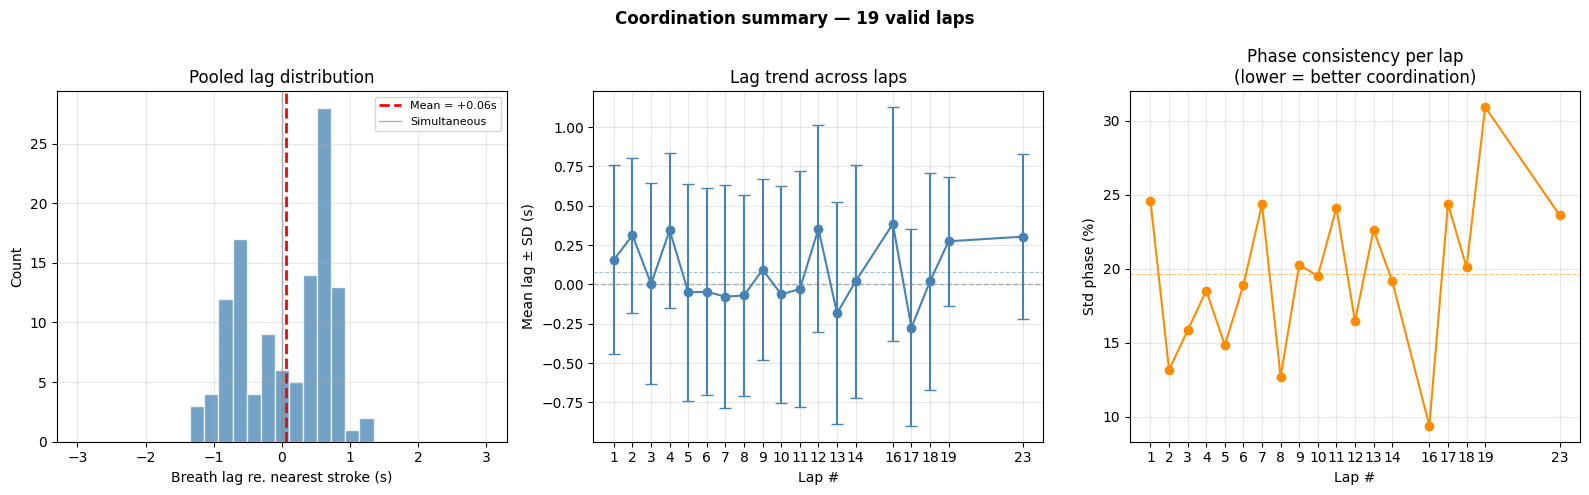

Overall: mean_lag = +0.062s
         std_lag  = 0.667s
         mean_phase = 44.7%
         std_phase  = 22.2%  ← primary outcome variable


In [ ]:
# Step 13 — Coordination summary plots (valid laps only)

all_lags   = np.concatenate([r["lags"]   for r in valid_results])
all_phases = np.concatenate([r["phases"] for r in valid_results])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Coordination summary — {len(valid_results)} valid laps",
             fontsize=12, fontweight="bold")

# lag histogram
axes[0].hist(all_lags, bins=np.linspace(-3, 3, 30),
             color="steelblue", alpha=0.75, edgecolor="white")
axes[0].axvline(np.mean(all_lags), color="red", lw=2, ls="--",
                label=f"Mean = {np.mean(all_lags):+.2f}s")
axes[0].axvline(0, color="gray", lw=1, alpha=0.6, label="Simultaneous")
axes[0].set_xlabel("Breath lag re. nearest stroke (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Pooled lag distribution")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# mean lag per lap
laps_n = [r["lap"] for r in valid_results]
means  = [r["mean_lag_s"]  for r in valid_results]
stds   = [r["std_lag_s"]   for r in valid_results]
axes[1].errorbar(laps_n, means, yerr=stds, fmt="o-", color="steelblue",
                 capsize=4, lw=1.5, ms=6)
axes[1].axhline(0, color="gray", lw=1, ls="--", alpha=0.6)
axes[1].axhline(np.mean(means), color="steelblue", lw=0.8, ls="--", alpha=0.5)
axes[1].set_xlabel("Lap #"); axes[1].set_ylabel("Mean lag ± SD (s)")
axes[1].set_title("Lag trend across laps")
axes[1].set_xticks(laps_n); axes[1].grid(True, alpha=0.3)

# std phase per lap (coordination consistency)
std_phases = [r["std_phase_pct"] for r in valid_results]
axes[2].plot(laps_n, std_phases, "o-", color="darkorange", lw=1.5, ms=6)
axes[2].axhline(np.mean(std_phases), color="darkorange", lw=0.8, ls="--", alpha=0.5)
axes[2].set_xlabel("Lap #"); axes[2].set_ylabel("Std phase (%)")
axes[2].set_title("Phase consistency per lap\n(lower = better coordination)")
axes[2].set_xticks(laps_n); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Overall: mean_lag = {np.mean(all_lags):+.3f}s")
print(f"         std_lag  = {np.std(all_lags):.3f}s")
print(f"         mean_phase = {np.mean(all_phases):.1f}%")
print(f"         std_phase  = {np.std(all_phases):.1f}%  ← primary outcome variable")

## Step 14 — Automatic Data Quality Flags

For each lap, flag potentially invalid data so you know what to exclude before analysis.

In [ ]:
# Step 14 — Quality flags + export

quality = []
for r in valid_results:
    seg  = swim_segs[r["lap"] - 1]
    mask = (D["t"] >= seg["start_s"]) & (D["t"] <= seg["end_s"])
    frozen = float((np.abs(D.loc[mask, "h_rx"].values) < 0.005).mean() * 100)
    flags = []
    if frozen > 20:                        flags.append(f"HEAD_FROZEN({frozen:.0f}%)")
    # impossible number of breathing range
    if not (3 <= r["breath_rate"] <= 15):  flags.append("BR_IMPLAUSIBLE")
    if r["cycles_per_breath"] > 6:         flags.append("CPB_HIGH")
    w_s = D.loc[mask, "w_roll"].std()
    h_s = D.loc[mask, "h_roll"].std()
    if (h_s < 10 and w_s > 20) or (w_s < 10 and h_s > 20):
        flags.append("MISMATCH")
    quality.append({
        "lap":          r["lap"],
        "dur_s":        r["dur_s"],
        "head_frozen%": round(frozen, 1),
        "n_breaths":    r["n_breaths"],
        "n_strokes":    r["n_strokes"],
        "cycles_per_breath": round(r["cycles_per_breath"], 2),
        "mean_lag_s":   round(r["mean_lag_s"], 3),
        "std_lag_s":    round(r["std_lag_s"], 3),
        "mean_phase%":  round(r["mean_phase_pct"], 1),
        "std_phase%":   round(r["std_phase_pct"], 1),
        "usable":       len(flags) == 0,
        "flags":        ", ".join(flags) if flags else "OK",
    })

qdf = pd.DataFrame(quality)
display(qdf)
print(f"\nUsable laps: {qdf['usable'].sum()} / {len(qdf)}")

# uncomment to download
# from google.colab import files as cfiles
# qdf.round(4).to_csv("swim_results.csv", index=False)
# cfiles.download("swim_results.csv")

,lap,dur_s,head_frozen%,n_breaths,n_strokes,cycles_per_breath,mean_lag_s,std_lag_s,mean_phase%,std_phase%,usable,flags
0,1,26.0,1.2,9,15,1.20,0.158,0.602,52.5,24.6,False,BR_IMPLAUSIBLE
1,2,25.0,0.6,5,16,2.11,0.312,0.494,32.0,13.2,True,OK
2,3,28.0,1.2,5,18,2.12,0.004,0.639,37.5,15.8,True,OK
3,4,27.0,1.3,5,13,1.68,0.344,0.494,36.5,18.5,True,OK
4,5,24.0,0.7,6,14,1.97,-0.050,0.689,46.1,14.8,True,OK
5,6,29.0,1.2,6,15,1.62,-0.047,0.657,43.8,18.9,True,OK
6,7,26.0,0.9,8,15,1.43,-0.077,0.709,55.4,24.4,False,BR_IMPLAUSIBLE
7,8,24.0,0.6,6,16,2.22,-0.070,0.641,49.3,12.7,True,OK
8,9,28.0,1.1,7,15,1.49,0.094,0.574,30.6,20.3,True,OK
9,10,24.0,1.3,6,13,1.85,-0.063,0.688,44.7,19.5,True,OK



Usable laps: 13 / 19
